# Glanerbeek stations: 

## Field 1
| Datalogger | Name             | Time                     |
| ---------: | ---------------- | ------------------------ |
|   z6-21176 | F1_1_ATMOS_SMST1 | starting from 01-06-2023 |
|   z6-21178 | F1_2_SMST2       | starting from 01-06-2023 |
|   z6-25928 | F1_3_SMST3       | starting from 15-05-2024 |
|   z6-28931 | F1_5_WP_SMST     | starting from 19-06-2025 |
|   z6-24636 | F1_6_WP_SMST     | starting from 19-06-2025 |

## Field 2
| Datalogger | Name             | Time                     |
| ---------: | ---------------- | ------------------------ |
|   z6-21177 | F2_1_ATMOS_SMST1 | starting from 01-06-2023 |
|   z6-21179 | F2_2_SMST2       | starting from 01-06-2023 |
|   z6-30173 | F2_3_WP_SMST     | starting from 19-06-2025 |



# Soil Moisture and Tempearature Monitoring Stations @ Glanerbeek

Note: no need to download the data again; all data is available in `timeseries`; use this to re-create the pandas dataframes

In [ ]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import MajiSysUtil as msu
import pandas as pd

loggerNames=[('z6-21176','F1_1_ATMOS_SMST1'), ('z6-21178','F1_2_SMST2')]

loggers = [loggerNames[0]] # 0-Station1; 1-Station2; 2-Station3

# All donwnloadable parameters
parameters = ['Soil moisture', 'Soil temperature', 'Air Pressure', 'Vapor Pressure Deficit', 'Air Temperature observation', 'Wind speed observation', 'Precipitation', 'Radiation observation']
maxdate = datetime.now()
mindate = maxdate - timedelta(days=100)

# Start Downloading Data
print ("Start downloading station data...")
timeseries = msu.downloadTimeseries(loggers, mindate, maxdate)
data = msu.groupByParameter(timeseries, parameters, loggers)
PandaConvertData = msu.toPandas(data)
print ("Data download completed!")

# Get soil moisture, temperature data
soilmoisture = PandaConvertData['Soil moisture']
soilTemperature = PandaConvertData['Soil temperature']


Start downloading station data...
Data download completed!


In [5]:
#Try to fix the color sequence for different depths, to avoid potential confusions
#Also plot the depth even there are missing data (e.g., 20cm for the Field 1 logger z6-21178).
colorsSM = {'Soil moisture 2.5cm':'blue', 'Soil moisture 5cm':'orange',  'Soil moisture 10cm':'green', 'Soil moisture 20cm':'red', 'Soil moisture 40cm':'purple', 'Soil moisture 80cm':'brown'}
colorsST = {'Soil temperature 2.5cm':'blue', 'Soil temperature 5cm':'orange',  'Soil temperature 10cm':'green', 'Soil temperature 20cm':'red', 'Soil temperature 40cm':'purple', 'Soil temperature 80cm':'brown'}

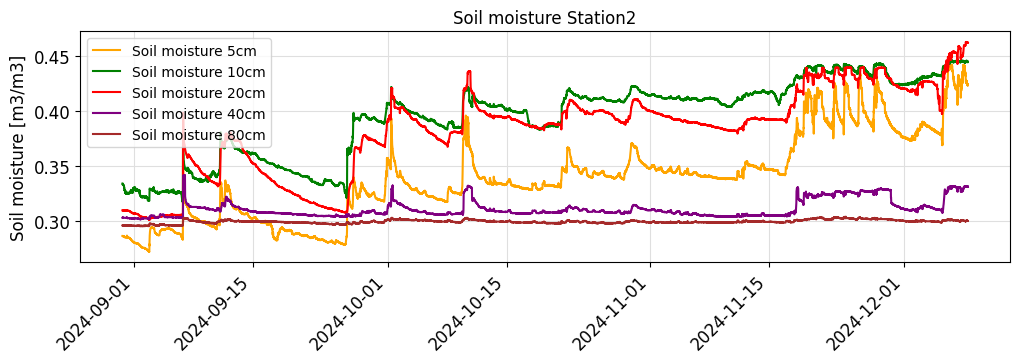

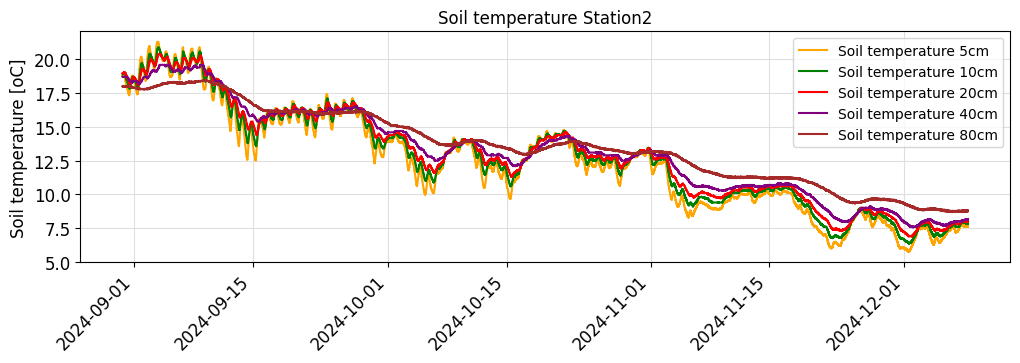

In [6]:
# Soil Moisture Plot
nr_loggers = len(soilmoisture)
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(soilmoisture):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    msu.plotGraphPandas(logger_data, logger_id, unit, colorsSM)
        

# Soil Temperature Plot
nr_loggers = len(soilTemperature)
fig = plt.figure(figsize=(12, 3*nr_loggers))
for ix, logger_item in enumerate(soilTemperature):
    logger_id = logger_item[0]
    unit = logger_item[1]
    logger_data = logger_item[2]
    ax1 = plt.subplot(nr_loggers, 1, ix + 1)
    if ix + 1 < nr_loggers: # disable x-labels (date) for all plots except the last one
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    #ax1.plot(airTemperature.index, airTemperature['Air Temperature observation'], label='Air Temperature', color='darkgrey')
    msu.plotGraphPandas(logger_data, logger_id, unit, colorsST)
    legend = ax1.legend(loc='upper right', fontsize=10)